# Load data for GNN PROTAC splitter - Node classifier - Experimental Architectures

# ToDo

1. Make test set from AZ data. Make AZ data which is in public and AZ data which is not in public.

1.5 Make test set based on "cluster-leave-one-out"

1.75 5-fold cross validation - Check if it is overfitting or not

1.8 Other methods to see if the GNN overfits or not

2. Fix points of improvement for BoundaryNode GNN. Notes down below.

2.5 Make a dataframe for all evaluation metrics. Export to CSV and analyze it in Excel.
    * Is it correct to say that some protacs have "no" linker? Some have their length of their linker equal to zero.
        IF it is incorrect, then the dataprocessing may need revisions.

3. Clean up code.



1. Generate a complete dataset of PROTACs of all combinations between POI, Linker, E3
    1.1 Use a smaller subset of these rather than generating new ones.

2. Save the set of smiles for the anonymous MS for each substructure. Use these when generating the test set.

3. Make the nameing from Stefanos and Evas code congruent. Standardize mine and theirs.

4. Have the PROTACdataset class call on the same function as prepare_data. So If I update the function, it automatically applies to both. To prevent mismatch / outdated functions.

5. Retry adding rings to linker an applying MS

6. Make the subset selection of the complete set of random PROTACs to be random but reproducible with a seed.

7. Multiple substructure matches (about ~20 public protacs are lost at the moment. Unknown how many internal)


In [ ]:
#split the abstract substructures into test and train/val sets
    #test set
        #choose the 3rd, 4th and 5th most commonly occuring abstract POI among the real public dataset
            #do so for the linker and E3 as well
                #Note: Each abstract substructure can have multiple exact forms
            #preferably I want the substructures to be quite different in size and atom composition - Look at the real substructures
            # I could probably choose a few more linkers as they are more diverse than POIs and E3s
        #Have 3 test sets of all real protacs the POI, linker  OR  E3 
            #Way to show that it works on "real" protacs
            #Will test for unknown POI, Linker or E3
        #Generate a test set combining these substructures
            #These PROTACs will test for completely unknown protacs
    #train/validation
        #Remove those abstract substructures that were chosen for the test set
        #Generate all combinations of these substructures
        #Randomly split all generated protacs into training set and validation set 
            #Note: I want validation to have same distribution as training, where as test should be "out-of-distribution"

In [ ]:
# Standard library imports
import os
import sys
import io

# Data handling and scientific computing
import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy.linalg import inv

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split
from torch_geometric.nn import GCNConv, NNConv
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

# RDKit for cheminformatics
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, GetPeriodicTable
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdchem
from rdkit.Chem import rdmolops
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import rdMolHash


# NetworkX for network analysis
import networkx as nx

# Matplotlib for plotting and visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# Other utilities
from tqdm import tqdm
from PIL import Image

# External datasets
from datasets import load_dataset


import re
import random


from IPython.display import display

sys.path.append('./Code/TestingGround/src/models/')

In [ ]:
from all_functions import *

# Playground

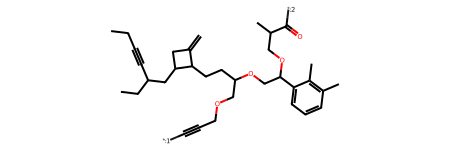

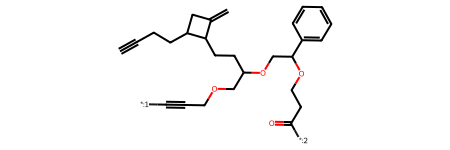

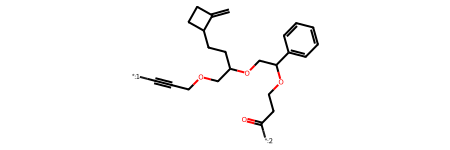

In [45]:
# Example usage
mol = Chem.MolFromSmiles('[*:1]C#CCOCC(CCC1C(=C)CC1CC(C#CCC)CC)OCC(c1cccc(c1C)C)OCC(C)C(=O)[*:2]')
display(mol)
display(remove_non_ring_atoms(mol)) #Custom function
display(linker_mol_to_ms(mol)) #A combination of RDKit functions. 

# User inputs:
Note that new datasets (as in a new "dataname") have all descriptors calculated from scratch, which is then saved. If there exists a dataset with a given dataname, it is retrived instead.

In [ ]:
Highlighted_graph_descriptors = ['betweenness', 'local_betweenness_5', 'local_eigenvectors_x', 'local_normAvgShortestPath_5', 'local_prod_betweenness_avgShortestPath_4']   ##Which graph descriptors to calculate for the data and use to train the GNN model. There exists more graph descriptors
Existing_datanames = ['NoGraphDesc','NoGraphDesc_20K']



#user input
graph_descriptor_list = []#Highlighted_graph_descriptors
dataname = "NoGraphDesc_2K"  #Existing_datanames[0] # Which dataset to use
num_random_protacs = 2000
name_dataset_aibe = "80-20-split"

load_testsets = False

pregen_or_load_rand_protacs = False #not yet implemented



# Core functions 

## Graph descriptor functions

More graph descriptors:
https://en.wikipedia.org/wiki/Centrality: Percolation centrality, Harmonic centrality, Freeman centralization, Dissimilarity-based centrality measures



Established node descriptors: bonacich_custom, betweenness_custom, eigenvector_custom, katz_custom      
Personal node descriptors: ovality, eccentricity, major_minor_axis_ratio, general_wiener_vector

Global -> Node pair: general_wiener_matrix, general_modified_wiener_matrix 

Global descriptors: wiener_index, hyper_wiener_index, general_modified_wiener_index, average_shortest_path_custom

# Datasets


OBS Work in progress

## Download data

In [ ]:
#name_dataset_aibe = "80-20-split"
dataset_aibe = load_dataset("ailab-bio/PROTAC-Substructures", name_dataset_aibe) #download
train_dataset = dataset_aibe['train']
validation_dataset = dataset_aibe['validation']

train_texts = train_dataset['text']
train_labels = train_dataset['labels']

validation_texts = validation_dataset['text']
validation_labels = validation_dataset['labels']

## Load data & remove ambigous substructure matches (matching can be improved)

In [ ]:
substructures_list = train_labels + validation_labels
protac_smi_list = train_texts + validation_texts
poi_smi_r_list = []
linker_smi_r_list = []
e3_smi_r_list = []
for substructures in substructures_list:
    poi_smi_r, linker_smi_r, e3_smi_r = substructure_split_sort(substructures)
    poi_smi_r_list.append(poi_smi_r)
    linker_smi_r_list.append(linker_smi_r)
    e3_smi_r_list.append(e3_smi_r)

pub_protac_and_substructure_smi_df = pd.DataFrame({
    'smiles': protac_smi_list,
    'POI_R': poi_smi_r_list,
    'Linker_R': linker_smi_r_list,
    'E3_R': e3_smi_r_list
})

In [ ]:
#Removes protacs with ambigous substructure matches and splits dataframe
pub_protac_smiles_df_prepared, pub_substructure_smiles_df_prepared = prepare_data_set(pub_protac_and_substructure_smi_df, 'smiles', 'POI_R', 'Linker_R', 'E3_R')

## Generate random protacs for training and validation

In [ ]:
# Initialize lists to hold the split substructure components
pois = []
linkers = []
e3s = []

chosen_substructures = pub_substructure_smiles_df_prepared

# Iterate through the 'substructures' column and apply the split function
for substructure_smiles in chosen_substructures['substructures']:
    poi, linker, e3 = substructure_split_sort(substructure_smiles)
    pois.append(poi)
    linkers.append(linker)
    e3s.append(e3)

    # Create a new DataFrame with the split components
Substructuressmiles_split_df = pd.DataFrame({
    'POI': pois,
    'Linker': linkers,
    'E3': e3s
})
Substructuressmiles_split_df

In [ ]:
#smi = "[*:1]C#CCOCC(C)OCC(c1cccc(c1C)C)OCC(C)C(=O)[*:2]"
#display(Chem.MolFromSmiles(smi))
#a = get_anonymous_murcko(smi)
#display(Chem.MolFromSmiles(a))

In [ ]:
for col in Substructuressmiles_split_df.columns:
    Substructuressmiles_split_df = generate_anonymous_murcko_in_df(Substructuressmiles_split_df, col)

In [ ]:
Substructuressmiles_split_df['POI_AnonMS'] = Substructuressmiles_split_df['POI_AnonMS'].apply(standardize_smiles)
Substructuressmiles_split_df['Linker_AnonMS'] = Substructuressmiles_split_df['Linker_AnonMS'].apply(standardize_smiles)
Substructuressmiles_split_df['E3_AnonMS'] = Substructuressmiles_split_df['E3_AnonMS'].apply(standardize_smiles)

# Extract unique standardized SMILES
unique_abstract_poi_smiles = Substructuressmiles_split_df['POI_AnonMS'].dropna().unique().tolist()
unique_abstract_linker_smiles = Substructuressmiles_split_df['Linker_AnonMS'].dropna().unique().tolist()
unique_abstract_e3_smiles = Substructuressmiles_split_df['E3_AnonMS'].dropna().unique().tolist()

In [20]:
# Create mappings for POI, Linker, and E3
poi_group_mapping = create_group_index_mapping(unique_abstract_poi_smiles)
linker_group_mapping = create_group_index_mapping(unique_abstract_linker_smiles)
e3_group_mapping = create_group_index_mapping(unique_abstract_e3_smiles)

# Assign group indices
Substructuressmiles_split_df['POI_Group'] = Substructuressmiles_split_df['POI_AnonMS'].map(poi_group_mapping)
Substructuressmiles_split_df['Linker_Group'] = Substructuressmiles_split_df['Linker_AnonMS'].map(linker_group_mapping)
Substructuressmiles_split_df['E3_Group'] = Substructuressmiles_split_df['E3_AnonMS'].map(e3_group_mapping)



# Collect unique substructures for POIs, linkers, and E3s
unique_poi_substructures = collect_unique_substructures(Substructuressmiles_split_df, 'POI_Group', 'POI')
unique_linker_substructures = collect_unique_substructures(Substructuressmiles_split_df, 'Linker_Group', 'Linker')
unique_e3_substructures = collect_unique_substructures(Substructuressmiles_split_df, 'E3_Group', 'E3')



In [39]:
unique_substructures = [unique_poi_substructures, unique_linker_substructures, unique_e3_substructures]
num_unique_substructures = [0, 0, 0]
for idx, u_s in enumerate(unique_substructures):
    for k, v in u_s.items():
        num_unique_substructures[idx] += len(v)


print(f'Unique POI smiles: {num_unique_substructures[0]} \nUnique Linker smiles: {num_unique_substructures[1]} \nUnique E3 smiles: {num_unique_substructures[2]} ')
print(f'Number of total possible combinations: {num_unique_substructures[0]*num_unique_substructures[1]*num_unique_substructures[2]/1000000} million protacs \n')
print(f'unique_abstract_poi_smiles: {len(unique_abstract_poi_smiles)}')
print(f'unique_linker_smiles: {len(unique_abstract_linker_smiles)}')
print(f'unique_e3_smiles: {len(unique_abstract_e3_smiles)}')
print(f'Number of total possible abstract combinations: {len(unique_abstract_poi_smiles)*len(unique_abstract_linker_smiles)*len(unique_abstract_e3_smiles)/1000000} million protacs')




Unique POI smiles: 285 
Unique Linker smiles: 1034 
Unique E3 smiles: 58 
Number of total possible combinations: 17.09202 million protacs 

unique_abstract_poi_smiles: 172
unique_linker_smiles: 280
unique_e3_smiles: 26
Number of total possible abstract combinations: 1.25216 million protacs


In [ ]:
i=0 #reset index

In [ ]:
# Loop through each unique E3 SMILES string and visualize the molecule

for smi in unique_abstract_e3_smiles:
    mol = Chem.MolFromSmiles(smi)
    display(mol)
    i += 1
    if i % 40 == 0:
        break

In [ ]:
#split the abstract substructures into test and train/val sets
    #test set
        #choose the 3rd, 4th and 5th most commonly occuring abstract POI among the real public dataset
            #do so for the linker and E3 as well
                #Note: Each abstract substructure can have multiple exact forms
            #preferably I want the substructures to be quite different in size and atom composition - Look at the real substructures
            # I could probably choose a few more linkers as they are more diverse than POIs and E3s
        #Have 3 test sets of all real protacs the POI, linker  OR  E3 
            #Way to show that it works on "real" protacs
            #Will test for unknown POI, Linker or E3
        #Generate a test set combining these substructures
            #These PROTACs will test for completely unknown protacs
    #train/validation
        #Remove those abstract substructures that were chosen for the test set
        #Generate all combinations of these substructures
        #Randomly split all generated protacs into training set and validation set 
            #Note: I want validation to have same distribution as training, where as test should be "out-of-distribution"

In [46]:

# Select random substructures
random_poi = select_random_substructures(unique_poi_substructures)
random_linker = select_random_substructures(unique_linker_substructures)
random_e3 = select_random_substructures(unique_e3_substructures)

# Print the selected random substructures
print("Random POI Substructure:", random_poi)
print("Random Linker Substructure:", random_linker)
print("Random E3 Substructure:", random_e3)


Random POI Substructure: [*:1]#Cc1ccc(N2C(=S)N(c3cnc(C#N)c(C(F)(F)F)c3)C(=O)C23CCC3)cc1
Random Linker Substructure: [*:2]CCCCCn1cc(C[*:1])nn1
Random E3 Substructure: [*:2]C1CC(C(=O)NC2CCCc3ccccc32)N(C(=O)C(NC(=O)C(C)NC)C(C)(C)C)C1


In [ ]:
random_protacs_df = generate_random_protac_dataset(unique_poi_substructures, unique_linker_substructures, unique_e3_substructures, num_random_protacs)

In [ ]:
#split DataFrame into two train and validation
val_fraction = 0.15
num_random_train_protacs = int(num_random_protacs*(1-val_fraction)+0.5)
num_random_val_protacs = num_random_protacs-num_random_train_protacs

random_protacs_train_df = random_protacs_df.iloc[:num_random_train_protacs]
random_protacs_val_df = random_protacs_df.iloc[num_random_train_protacs:]

In [ ]:
PROTACsmiles_df_train_random, Substructuressmiles_df_train_random = prepare_data_set(random_protacs_train_df, p_column='protac_smiles', poi_column='poi', linker_column='linker', e3_column='e3')
PROTACsmiles_df_val_random, Substructuressmiles_df_val_random = prepare_data_set(random_protacs_val_df, p_column='protac_smiles', poi_column='poi', linker_column='linker', e3_column='e3')

# Load training and validation sets

In [ ]:
training_dataset = PROTACDataset(data=PROTACsmiles_df_train_random, substructures=Substructuressmiles_df_train_random, name=f'{dataname}_train_rand', graph_descriptor_list=graph_descriptor_list)
validation_dataset = PROTACDataset(data=PROTACsmiles_df_val_random, substructures=Substructuressmiles_df_val_random, name=f'{dataname}_val_rand', graph_descriptor_list=graph_descriptor_list)

## Load and prepare test sets

In [ ]:


if load_testsets:
    current_directory = os.getcwd()
    raw_data_path = os.path.join(current_directory, "..", "..", "data","raw")

    test_set_1_non_public_poi = pd.read_csv(raw_data_path +'/test_set_1_non_public_poi.csv')
    test_set_1_2_non_public_poi_and_linker = pd.read_csv(raw_data_path +'/test_set_1_2_non_public_poi_and_linker.csv')
    test_set_2_non_public_e3 = pd.read_csv(raw_data_path +'/test_set_2_non_public_e3.csv')
    test_set_2_2_non_public_e3_and_linker = pd.read_csv(raw_data_path +'/test_set_2_2_non_public_e3_and_linker.csv')
    test_set_3_non_public_linker = pd.read_csv(raw_data_path +'/test_set_3_non_public_linker.csv')
    test_set_4_non_public_protac = pd.read_csv(raw_data_path +'/test_set_4_non_public_protac.csv')
    test_set_5_public_protac = pd.read_csv(raw_data_path +'/test_set_5_public_protac.csv')

    test_set_names_core = ['test_set_1_non_public_poi_v1', 'test_set_2_non_public_e3_v1', 'test_set_3__non_public_linker_v1', 'test_set_4_non_public_protac', 'test_set_5_public_protac_v1', 'test_set_1_2_non_public_poi_and_linker', 'test_set_2_2_non_public_e3_and_linker']
    test_set_names = [s + dataname for s in test_set_names_core]
    test_sets = [test_set_1_non_public_poi, test_set_2_non_public_e3, test_set_3_non_public_linker, test_set_4_non_public_protac, test_set_5_public_protac, test_set_1_2_non_public_poi_and_linker, test_set_2_2_non_public_e3_and_linker]

    test_set_1_protacs, test_set_1_substructures = prepare_data_set(test_sets[0], 'Structure', 'POI Smiles R', 'linker', 'e3 Smiles R')
    test_set_2_protacs, test_set_2_substructures = prepare_data_set(test_sets[1], 'Structure', 'POI Smiles R', 'linker', 'e3 Smiles R')
    test_set_3_protacs, test_set_3_substructures = prepare_data_set(test_sets[2], 'Structure', 'POI Smiles R', 'linker', 'e3 Smiles R')
    test_set_4_protacs, test_set_4_substructures = prepare_data_set(test_sets[3], 'Structure', 'POI Smiles R', 'linker', 'e3 Smiles R')
    test_set_5_protacs, test_set_5_substructures = prepare_data_set(test_sets[4], 'Structure', 'POI Smiles R', 'linker', 'e3 Smiles R')
    test_set_1_2_protacs, test_set_1_2_substructures = prepare_data_set(test_sets[5], 'Structure', 'POI Smiles R', 'linker', 'e3 Smiles R')
    test_set_2_2_protacs, test_set_2_2_substructures = prepare_data_set(test_sets[6], 'Structure', 'POI Smiles R', 'linker', 'e3 Smiles R')

    test_dataset_1 = PROTACDataset(data=test_set_1_protacs, substructures=test_set_1_substructures, name=test_set_names[0])
    test_dataset_2 = PROTACDataset(data=test_set_2_protacs, substructures=test_set_2_substructures, name=test_set_names[1])
    test_dataset_3 = PROTACDataset(data=test_set_3_protacs, substructures=test_set_3_substructures, name=test_set_names[2])
    test_dataset_4 = PROTACDataset(data=test_set_4_protacs, substructures=test_set_4_substructures, name=test_set_names[3])
    test_dataset_5 = PROTACDataset(data=test_set_5_protacs, substructures=test_set_5_substructures, name=test_set_names[4])
    test_dataset_1_2 = PROTACDataset(data=test_set_1_2_protacs, substructures=test_set_1_2_substructures, name=test_set_names[5])
    test_dataset_2_2 = PROTACDataset(data=test_set_2_2_protacs, substructures=test_set_2_2_substructures, name=test_set_names[6])